In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [11]:
import numpy
import pylab as plt
import os
import sys
import datetime as dtm

In [4]:
print('** working?')

** working?


In [28]:
log_filename='gpu0_1786652620.csv'
log_filename='gpu0_1786652214.csv'

#date_string = "2026-08-13 14:30:00"
#date_format = "%Y-%m-%d %H:%M:%S"
dtm_format = "%Y/%m/%d%H:%M:%S.%f"

# Convert string to datetime object
#dt_object = datetime.strptime(date_string, date_format)

In [29]:
log_data = []
def fmt_mem_temp(x):
    if isinstance(x, float) or isinstance(x, int):
        return x
    #
    if x.replace(' ', '').upper()=='N/A':
        return None
    #
    # this could be an int(), to make the dataset more compact. Then again, that could change with version, and
    #  ultimately we want float-like properties.
    return float(x)

with open(log_filename, 'r') as fin:
    cols = fin.readline().replace(' ', '').split(',')
    #
    # this'll be a bit of a sloppy hack for now. Future versions might include more rigorous formatting and
    #  data wrangling
    for rw in fin:
        #print(f'** {rw}')
        rws = rw[:-1].replace(' ', '').split(',')
        #
        log_data += [(dtm.datetime.strptime(rws[0], dtm_format), \
                      float(rws[1]),
                      fmt_mem_temp(rws[2]),
                      float(rws[3][:-1]),
                      float(rws[4][:-3]),
                      float(rws[5][:-3]),
                      rws[6] )]
                      
    #
# for rw in log_data:
#     print(rw)

log_data_array = numpy.array(log_data, dtype=[(nm,tp) for nm,tp in zip(cols, ['datetime64[us]', 'f8', 'f8', 'f8', 'f8', 'f8',
                                                                              f'S{max([len(rw[6]) for rw in log_data])}'])])

In [30]:
print('** log_data_array: ', log_data_array.dtype.names)

** log_data_array:  ('timestamp', 'temperature.gpu', 'temperature.memory', 'power.draw[W]', 'clocks.current.sm[MHz]', 'clocks.current.memory[MHz]', 'clocks_event_reasons.active\n')


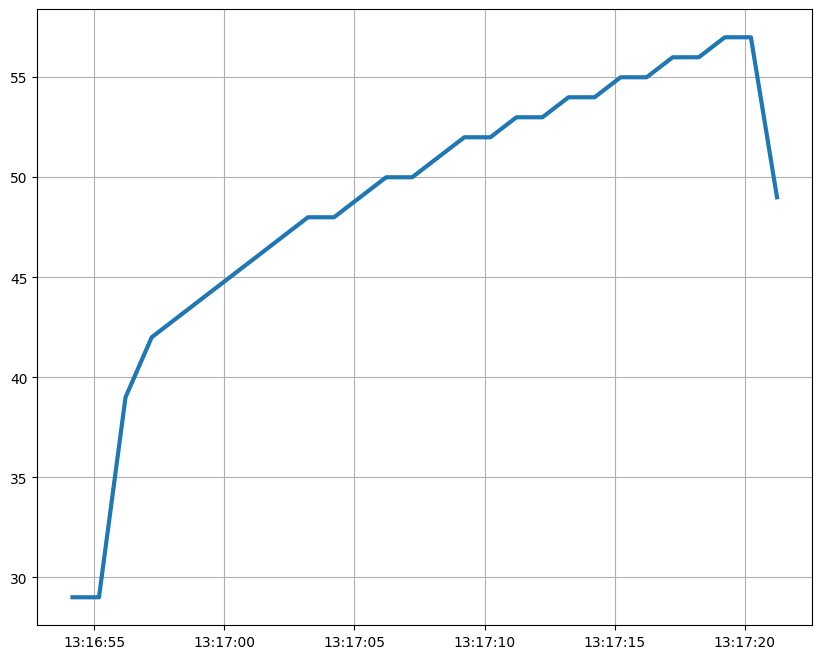

In [31]:
# for s in log_data_array['temperature.gpu']:
#     print(s)

fg  = plt.figure(figsize=(10,8))
ax1 = fg.add_subplot(1,1,1)
ax1.plot(log_data_array['timestamp'], log_data_array['temperature.gpu'], ls='-', lw=3)
ax1.grid()